# Gastrointestinal transit in critically ill trauma patients — a statistical re-analysis

**Replication of:** Rauch S. *et al.* (2012). *Use of wireless motility capsule to determine gastric emptying and small intestinal transit times in critically ill trauma patients.* Journal of Critical Care 27(5), 534.e7–534.e12.

**Course:** Statistics & Machine Learning (ADSA04), M.Sc. Applied Data Science & AI, SRH University — Winter term 2025/26
**Author:** Chandana Gurusiddappa

The study compares **8 mechanically ventilated trauma patients** with **87 healthy volunteers**. Every participant swallowed a *SmartPill* wireless motility capsule that records pH, pressure and temperature as it travels through the gut. The research question:

> Are gastric emptying time (GE) and small-bowel transit time (SB) longer in critically ill trauma patients than in healthy people?

The original coursework was done in JASP. This notebook reproduces every result in Python so that the analysis is transparent and re-runnable, and it extends it with normality checks, effect sizes, an odds ratio, distribution fitting and a multivariable regression.

| Section | Method |
|---|---|
| 1 | Study design and variable types |
| 2 | Baseline characteristics — *t*-test, Mann–Whitney *U*, χ², Fisher's exact |
| 3 | Primary outcomes — Shapiro–Wilk, Welch *t*, Mann–Whitney *U*, Bonferroni |
| 4 | Delayed gastric emptying — 2 × 2 table and odds ratio |
| 5 | GE time by gender and by race — one-way ANOVA, Levene, Kruskal–Wallis |
| 6 | Probability-distribution fitting — Normal vs Exponential vs Gamma (KS test) |
| 7 | Correlation — Pearson and Spearman |
| 8 | Multiple linear regression for SB time |
| 9 | Conclusions and limitations |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats

DATA = Path("data/smartpill.csv")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

ILL, HEALTHY = "Critically ill", "Healthy"
PALETTE = {ILL: "#C8553D", HEALTHY: "#2D7D9A"}
ALPHA_PRIMARY = 0.05 / 2  # Bonferroni: two primary outcomes (GE, SB)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.precision", 3)


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", facecolor="white")


def fmt_p(p):
    return "< .001" if p < 0.001 else f"{p:.3f}".lstrip("0")


def p_str(p):
    return "p < .001" if p < 0.001 else f"p = {fmt_p(p)}"


def log_axis(ax, ticks):
    ax.set_yscale("log")
    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_minor_formatter(plt.NullFormatter())

## 1. Study design and data

* **Design:** prospective observational cohort (ClinicalTrials.gov NCT01159002) with an external control group. The 8 patients were intubated, ventilated, APACHE III > 25, with major trauma and intracranial haemorrhage. The 87 volunteers come from a separate multicentre trial. There was no randomisation.
* **Primary outcomes:** gastric emptying time (`GE.Time`) and small-bowel transit time (`SB.Time`), in hours. Because there are two primary outcomes, the significance level is Bonferroni-corrected to **α = 0.025**.
* **Secondary outcome:** whole-gut transit time (`WG.Time`).
* **Data source:** the public *Smart Pill* dataset (A. Nowacki, Cleveland Clinic; TSHS Resources Portal), distributed in the R package [`medicaldata`](https://github.com/higgi13425/medicaldata).

In [2]:
df = pd.read_csv(DATA)
df["GroupLabel"] = df["Group"].map({0: ILL, 1: HEALTHY})
df["GenderLabel"] = df["Gender"].map({0: "Female", 1: "Male"})
df["RaceLabel"] = df["Race"].map({1: "White", 2: "Black", 3: "Asian/PI", 4: "Hispanic", 5: "Other"})
ill, healthy = df[df.Group == 0], df[df.Group == 1]

print(f"{df.shape[0]} participants x {df.shape[1] - 3} variables  "
      f"({len(ill)} critically ill, {len(healthy)} healthy volunteers)")

95 participants x 22 variables  (8 critically ill, 87 healthy volunteers)


In [3]:
var_types = pd.DataFrame([
    ("Group", "Nominal (binary)", "0 = critically ill, 1 = healthy volunteer", "χ², Fisher, group factor"),
    ("Gender", "Nominal (binary)", "0 = female, 1 = male", "χ², Fisher's exact"),
    ("Race", "Nominal", "1–5 (White, Black, Asian/PI, Hispanic, Other)", "ANOVA / Kruskal–Wallis factor"),
    ("Age, Height, Weight", "Continuous (ratio)", "years, cm, kg", "t-test, Mann–Whitney"),
    ("GE / SB / C / WG Time", "Continuous (ratio)", "hours", "Mann–Whitney, regression"),
    ("S / SB / C Mean pH", "Continuous (interval)", "pH has no true zero", "descriptive"),
    ("Contractions", "Discrete (count)", "number of contractions", "Poisson / NB models"),
], columns=["Variable", "Type", "Coding / unit", "Suitable methods"])
var_types

,Variable,Type,Coding / unit,Suitable methods
0,Group,Nominal (binary),"0 = critically ill, 1 = healthy volunteer","χ², Fisher, group factor"
1,Gender,Nominal (binary),"0 = female, 1 = male","χ², Fisher's exact"
2,Race,Nominal,"1–5 (White, Black, Asian/PI, Hispanic, Other)",ANOVA / Kruskal–Wallis factor
3,"Age, Height, Weight",Continuous (ratio),"years, cm, kg","t-test, Mann–Whitney"
4,GE / SB / C / WG Time,Continuous (ratio),hours,"Mann–Whitney, regression"
5,S / SB / C Mean pH,Continuous (interval),pH has no true zero,descriptive
6,Contractions,Discrete (count),number of contractions,Poisson / NB models


In [4]:
missing = (df.drop(columns=["GroupLabel", "GenderLabel", "RaceLabel"])
             .groupby(df.GroupLabel).apply(lambda g: g.isna().sum()).T)
missing[missing.sum(axis=1) > 0]

GroupLabel,Critically ill,Healthy
Race,8,0
GE.Time,1,2
SB.Time,1,4
C.Time,8,5
WG.Time,0,1
S.Contractions,8,6
S.Sum.of.Amplitudes,8,6
S.Mean.Peak.Amplitude,8,6
S.Mean.pH,8,6
SB.Contractions,8,8


For the critically ill patients, race and all pressure and pH measurements are missing, and so is colonic time (`C.Time`). That is why the group comparison is limited to demographics and the GE, SB and whole-gut transit times.

## 2. Baseline characteristics (Table 1)

In [5]:
def describe_continuous(var):
    a, b = ill[var].dropna(), healthy[var].dropna()
    t = stats.ttest_ind(a, b)                      # Student's t (as in JASP)
    u = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {
        "Variable": var,
        f"{ILL} (n={len(a)})": f"{a.mean():.1f} ± {a.std():.1f}",
        f"{HEALTHY} (n={len(b)})": f"{b.mean():.1f} ± {b.std():.1f}",
        "t (df)": f"{t.statistic:.3f} ({len(a) + len(b) - 2})",
        "p (t-test)": fmt_p(t.pvalue),
        "U": u.statistic,
        "p (Mann–Whitney)": fmt_p(u.pvalue),
    }

table1 = pd.DataFrame([describe_continuous(v) for v in ["Age", "Height", "Weight"]])
table1

,Variable,Critically ill (n=8),Healthy (n=87),t (df),p (t-test),U,p (Mann–Whitney)
0,Age,40.2 ± 12.0,37.2 ± 12.3,0.665 (93),.508,406.5,.437
1,Height,176.2 ± 11.9,171.6 ± 10.7,1.154 (93),.252,460.5,.132
2,Weight,80.5 ± 19.7,77.2 ± 15.8,0.558 (93),.578,401.5,.477


In [6]:
gender_tab = pd.crosstab(df.GenderLabel, df.GroupLabel, margins=True, margins_name="Total")
chi2, p_chi2, dof, _ = stats.chi2_contingency(pd.crosstab(df.Gender, df.Group), correction=False)
odds, p_fisher = stats.fisher_exact(pd.crosstab(df.Gender, df.Group))
print(f"Chi-square: X2({dof}) = {chi2:.3f}, p = {fmt_p(p_chi2)}")
print(f"Fisher's exact: OR = {odds:.2f} (log OR = {np.log(odds):.3f}), p = {fmt_p(p_fisher)}")
gender_tab

Chi-square: X2(1) = 1.174, p = .279
Fisher's exact: OR = 0.41 (log OR = -0.891), p = .459


GroupLabel,Critically ill,Healthy,Total
GenderLabel,,,
Female,2,39,41
Male,6,48,54
Total,8,87,95


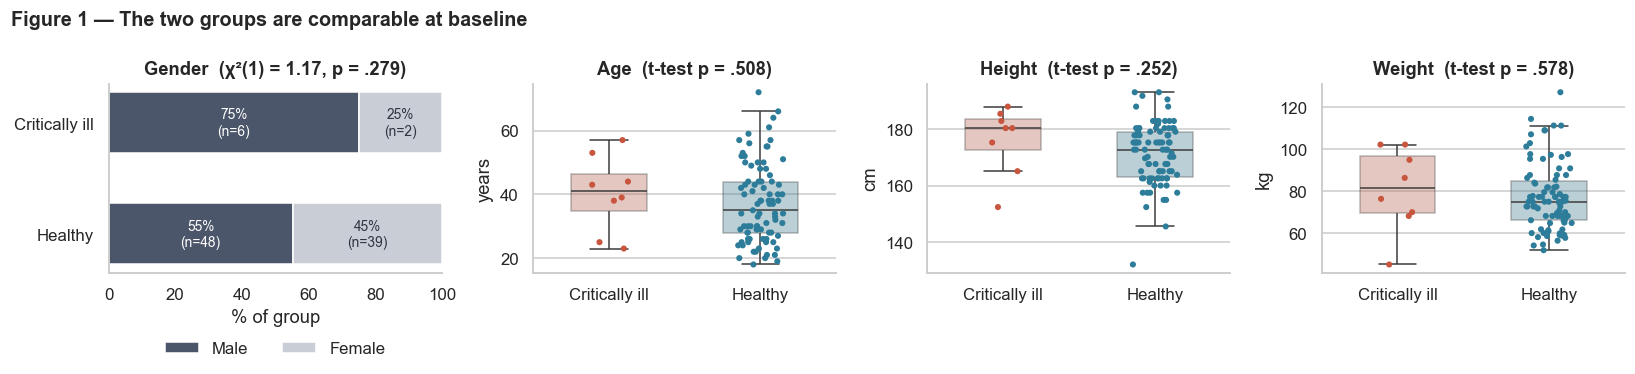

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), gridspec_kw={"width_ratios": [1.1, 1, 1, 1]})

share = pd.crosstab(df.GroupLabel, df.GenderLabel, normalize="index").loc[[ILL, HEALTHY]] * 100
counts = pd.crosstab(df.GroupLabel, df.GenderLabel).loc[[ILL, HEALTHY]]
ax = axes[0]
left = np.zeros(2)
for sex, colour in [("Male", "#4C566A"), ("Female", "#C9CED6")]:
    ax.barh(share.index, share[sex], left=left, color=colour, label=sex, height=0.55)
    for i, (pct, n) in enumerate(zip(share[sex], counts[sex])):
        ax.text(left[i] + pct / 2, i, f"{pct:.0f}%\n(n={n})", ha="center", va="center",
                fontsize=9, color="white" if sex == "Male" else "#2E3440")
    left += share[sex].values
ax.set(xlim=(0, 100), xlabel="% of group", title=f"Gender  (χ²(1) = {chi2:.2f}, {p_str(p_chi2)})")
ax.invert_yaxis()
ax.grid(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=False)

for ax, (var, unit) in zip(axes[1:], [("Age", "years"), ("Height", "cm"), ("Weight", "kg")]):
    sns.boxplot(data=df, x="GroupLabel", y=var, hue="GroupLabel", palette=PALETTE, order=[ILL, HEALTHY],
                width=0.5, fliersize=0, ax=ax, legend=False, boxprops={"alpha": 0.35})
    sns.stripplot(data=df, x="GroupLabel", y=var, hue="GroupLabel", palette=PALETTE, order=[ILL, HEALTHY],
                  size=4, jitter=0.15, ax=ax, legend=False)
    p = stats.ttest_ind(ill[var], healthy[var]).pvalue
    ax.set(xlabel="", ylabel=unit, title=f"{var}  (t-test {p_str(p)})")

fig.suptitle("Figure 1 — The two groups are comparable at baseline", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "fig1_baseline")
plt.show()

**Interpretation.** The groups do not differ significantly in age, height, weight or gender (all p > .25). Gender: χ²(1) = 1.17, p = .28, and Fisher's exact test agrees (p = .46). So differences in transit time are unlikely to be explained by these demographic factors. Even so, 6 of the 8 patients are male, and with so few patients this check has little power.

## 3. Primary outcomes: gastric emptying, small-bowel and whole-gut transit time

In [8]:
OUTCOMES = {"GE.Time": "Gastric emptying", "SB.Time": "Small-bowel transit", "WG.Time": "Whole-gut transit"}

def iqr(s):
    return f"{s.median():.1f} [{s.quantile(.25):.1f}–{s.quantile(.75):.1f}]"

rows = []
for var, label in OUTCOMES.items():
    a, b = ill[var].dropna(), healthy[var].dropna()
    welch = stats.ttest_ind(a, b, equal_var=False)
    u = stats.mannwhitneyu(a, b, alternative="two-sided")
    r_rb = 1 - 2 * u.statistic / (len(a) * len(b))   # rank-biserial correlation
    alpha = ALPHA_PRIMARY if var != "WG.Time" else 0.05
    rows.append({
        "Outcome": label,
        f"{ILL} median [IQR], h": f"{iqr(a)}  (n={len(a)})",
        f"{HEALTHY} median [IQR], h": f"{iqr(b)}  (n={len(b)})",
        "Shapiro p (ill / healthy)": f"{fmt_p(stats.shapiro(a).pvalue)} / {fmt_p(stats.shapiro(b).pvalue)}",
        "Welch t, p": f"{welch.statistic:.2f}, {fmt_p(welch.pvalue)}",
        "Mann–Whitney U, p": f"{u.statistic:.1f}, {fmt_p(u.pvalue)}",
        "Rank-biserial r": round(-r_rb, 2),
        "α": alpha,
        "Significant": "yes" if u.pvalue < alpha else "no",
    })
primary = pd.DataFrame(rows)
primary

,Outcome,"Critically ill median [IQR], h","Healthy median [IQR], h",Shapiro p (ill / healthy),"Welch t, p","Mann–Whitney U, p",Rank-biserial r,α,Significant
0,Gastric emptying,13.9 [6.5–48.3] (n=7),3.0 [2.5–3.9] (n=85),.012 / < .001,"2.14, .076","573.0, < .001",0.93,0.025,yes
1,Small-bowel transit,6.7 [4.4–8.6] (n=7),3.8 [3.1–4.7] (n=83),.406 / < .001,"2.22, .067","461.5, .010",0.59,0.025,yes
2,Whole-gut transit,240.0 [204.0–312.0] (n=8),28.5 [21.8–45.6] (n=86),.008 / < .001,"3.53, .010","687.0, < .001",1.00,0.050,yes


**Which test to use.** Shapiro–Wilk rejects normality for GE time in both groups and for SB time in the healthy group. The data are strongly right-skewed and the patient group is tiny (n = 7). Welch's *t*-test gets a non-significant p = .076 for GE time only because one or two extreme values (up to 74 h) inflate the patient-group variance. The **Mann–Whitney *U* test** compares ranks, so it suits this data, and it is the primary test here, as in the original paper.

* **Gastric emptying:** median **13.9 h vs 3.0 h**, U = 573, p < .001. All 7 patients with a measurement rank above almost every volunteer (rank-biserial r ≈ 0.93).
* **Small-bowel transit:** median **6.7 h vs 3.8 h**, U = 461.5, p = .010. This stays significant at the Bonferroni level α = .025.
* **Whole-gut transit:** median **240 h vs 28 h**, U = 687, p < .001.

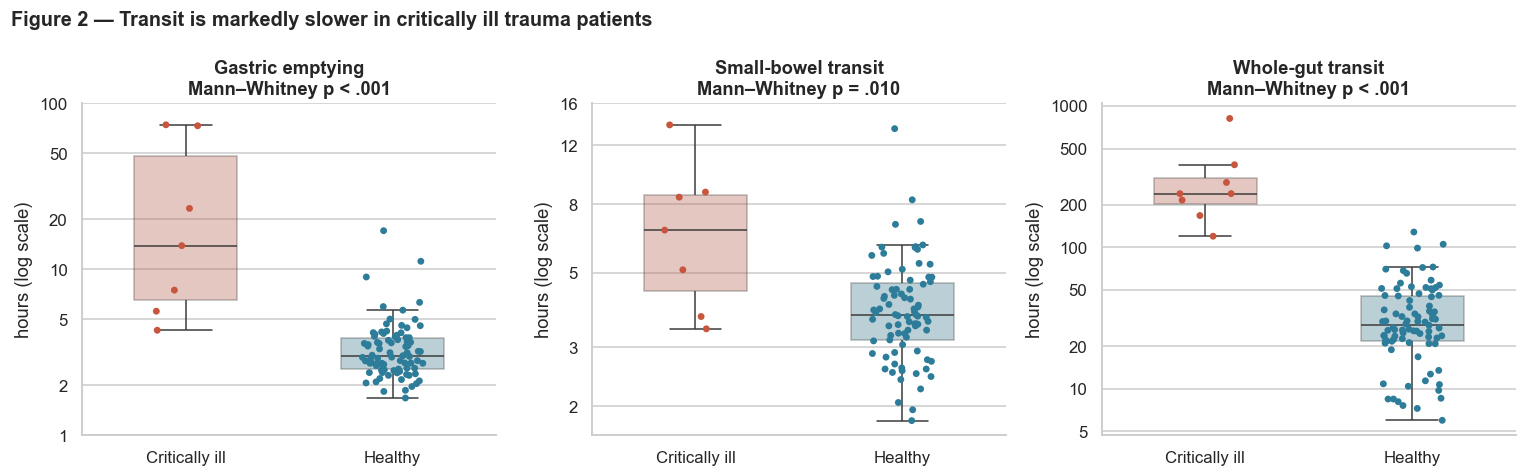

In [9]:
long = df.melt(id_vars="GroupLabel", value_vars=list(OUTCOMES), var_name="Outcome", value_name="Hours").dropna()
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, (var, label) in zip(axes, OUTCOMES.items()):
    d = long[long.Outcome == var]
    sns.boxplot(data=d, x="GroupLabel", y="Hours", hue="GroupLabel", palette=PALETTE, order=[ILL, HEALTHY],
                width=0.5, fliersize=0, ax=ax, legend=False, boxprops={"alpha": 0.35})
    sns.stripplot(data=d, x="GroupLabel", y="Hours", hue="GroupLabel", palette=PALETTE, order=[ILL, HEALTHY],
                  size=4.5, jitter=0.15, ax=ax, legend=False)
    log_axis(ax, {"GE.Time": [1, 2, 5, 10, 20, 50, 100], "SB.Time": [2, 3, 5, 8, 12, 16],
                  "WG.Time": [5, 10, 20, 50, 100, 200, 500, 1000]}[var])
    p = stats.mannwhitneyu(ill[var].dropna(), healthy[var].dropna()).pvalue
    ax.set(xlabel="", ylabel="hours (log scale)", title=f"{label}\nMann–Whitney {p_str(p)}")
fig.suptitle("Figure 2 — Transit is markedly slower in critically ill trauma patients",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "fig2_transit_times")
plt.show()

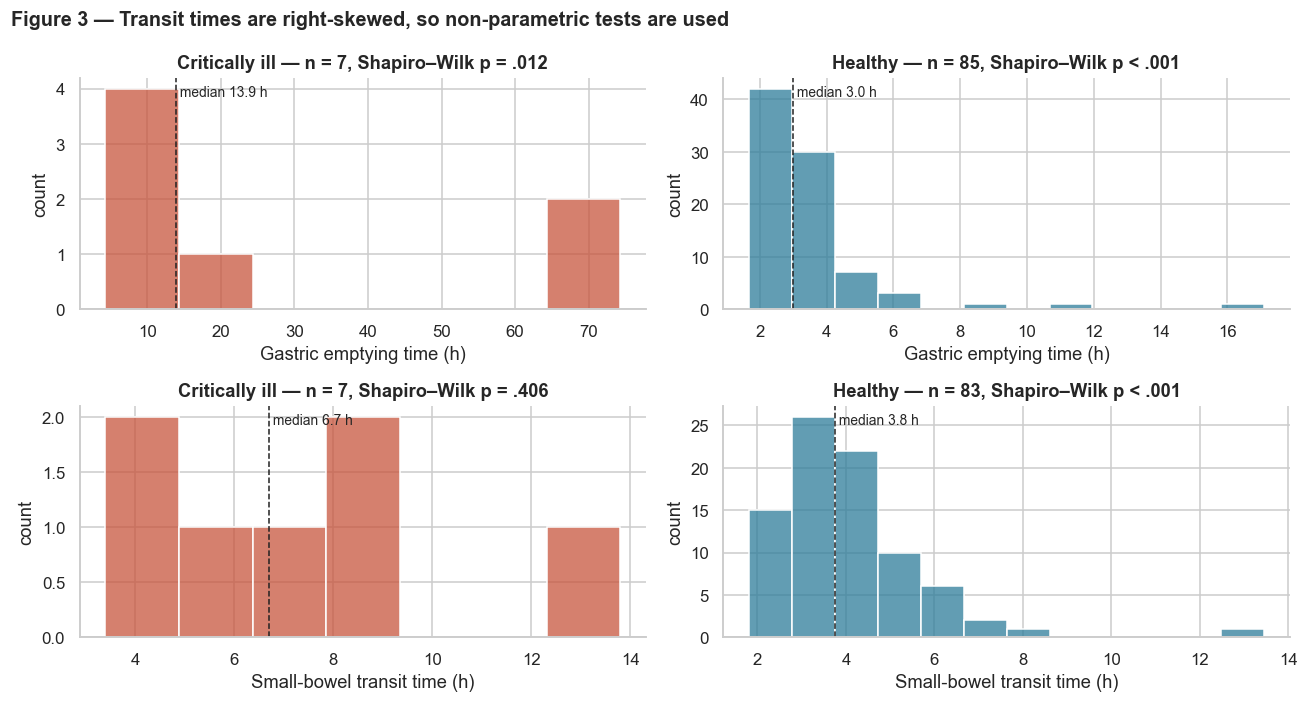

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
for row, var in enumerate(["GE.Time", "SB.Time"]):
    for col, (grp, data) in enumerate([(ILL, ill), (HEALTHY, healthy)]):
        ax = axes[row, col]
        x = data[var].dropna()
        sns.histplot(x, bins=12 if grp == HEALTHY else 7, color=PALETTE[grp], alpha=0.75, ax=ax, edgecolor="white")
        ax.axvline(x.median(), color="#222", ls="--", lw=1)
        ax.text(x.median(), ax.get_ylim()[1] * 0.92, f" median {x.median():.1f} h", fontsize=9)
        sw = stats.shapiro(x)
        ax.set(xlabel=f"{OUTCOMES[var]} time (h)", ylabel="count",
               title=f"{grp} — n = {len(x)}, Shapiro–Wilk {p_str(sw.pvalue)}")
fig.suptitle("Figure 3 — Transit times are right-skewed, so non-parametric tests are used",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "fig3_distributions")
plt.show()

## 4. Delayed gastric emptying: 2 × 2 table and odds ratio

Here gastric emptying counts as *delayed* if it is above the healthy volunteers' median (2.99 h). One cell of the table is zero (no patient had normal emptying), so the odds ratio uses the **Haldane–Anscombe correction**: +0.5 is added to every cell.

In [11]:
threshold = healthy["GE.Time"].median()
ge = df.dropna(subset=["GE.Time"]).assign(Delayed=lambda d: np.where(d["GE.Time"] > threshold, "Delayed", "Normal"))
tab = pd.crosstab(ge.GroupLabel, ge.Delayed).loc[[ILL, HEALTHY], ["Delayed", "Normal"]]
a, b, c, d = (tab.values + 0.5).ravel()
or_h = (a * d) / (b * c)
se = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
ci = np.exp(np.log(or_h) + np.array([-1.96, 1.96]) * se)
_, p_f = stats.fisher_exact(tab.values)
print(f"Threshold = {threshold:.2f} h")
print(f"Odds ratio (Haldane) = {or_h:.1f}, 95% CI {ci[0]:.1f} – {ci[1]:.1f};  Fisher's exact p = {fmt_p(p_f)}")
tab.assign(Total=tab.sum(axis=1))

Threshold = 2.99 h
Odds ratio (Haldane) = 15.4, 95% CI 0.9 – 277.3;  Fisher's exact p = .013


Delayed,Delayed,Normal,Total
GroupLabel,,,
Critically ill,7,0,7
Healthy,42,43,85


All 7 patients with a GE measurement had delayed emptying, compared with half of the volunteers by definition. Fisher's exact test is significant (p = .013). The odds ratio is about 15, but its 95% CI is very wide (0.9 – 277) because there are so few patients. That uncertainty is exactly why the original authors call this a *pilot* study.

## 5. Gastric emptying time by gender and by race (one-way ANOVA)

In [12]:
model_gender = smf.ols("Q('GE.Time') ~ C(Gender)", data=df).fit()
import statsmodels.api as sm
anova_gender = sm.stats.anova_lm(model_gender, typ=3)
print(anova_gender.round(3))
df.dropna(subset=["GE.Time"]).groupby("GenderLabel")["GE.Time"].agg(["count", "mean", "std", "median"])

              sum_sq    df      F  PR(>F)
Intercept    770.708   1.0  6.717   0.011
C(Gender)     81.330   1.0  0.709   0.402
Residual   10326.636  90.0    NaN     NaN


,count,mean,std,median
GenderLabel,,,,
Female,40,4.389,2.923,3.62
Male,52,6.286,13.998,2.77


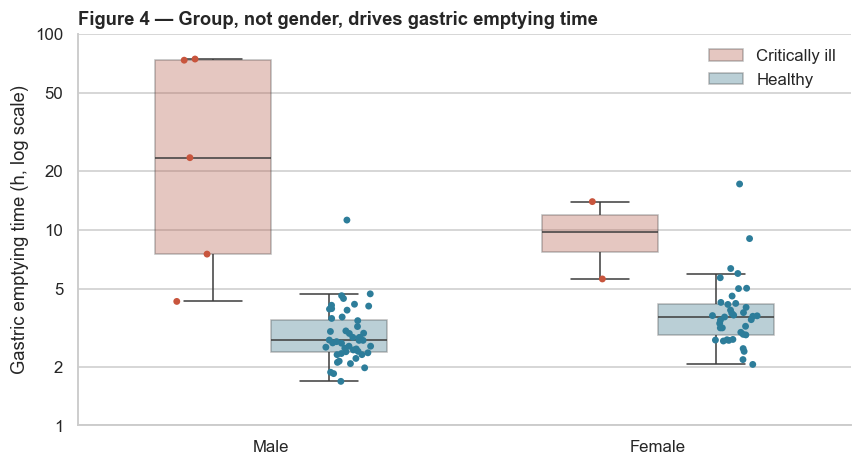

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.4))
d = df.dropna(subset=["GE.Time"])
sns.boxplot(data=d, x="GenderLabel", y="GE.Time", hue="GroupLabel", palette=PALETTE, hue_order=[ILL, HEALTHY],
            width=0.6, fliersize=0, ax=ax, boxprops={"alpha": 0.35})
sns.stripplot(data=d, x="GenderLabel", y="GE.Time", hue="GroupLabel", palette=PALETTE, hue_order=[ILL, HEALTHY],
              dodge=True, size=4.5, jitter=0.12, ax=ax, legend=False)
log_axis(ax, [1, 2, 5, 10, 20, 50, 100])
ax.set(xlabel="", ylabel="Gastric emptying time (h, log scale)")
ax.legend(title="", frameon=False)
ax.set_title("Figure 4 — Group, not gender, drives gastric emptying time", loc="left")
fig.tight_layout()
save(fig, "fig4_ge_by_gender")
plt.show()

**Gender.** ANOVA finds no gender effect: F(1, 90) = 0.71, p = .40. The male mean looks higher (6.3 h vs 4.4 h) only because 5 of the 7 patients with a GE measurement are male. The variances also differ by a factor of about 20, which breaks the equal-variance assumption, so this pooled ANOVA is fragile.

In [14]:
race = healthy[healthy.RaceLabel.isin(["White", "Black", "Asian/PI"])].dropna(subset=["GE.Time"])
groups = [g["GE.Time"].values for _, g in race.groupby("RaceLabel")]
f_r = stats.f_oneway(*groups)
lev = stats.levene(*groups, center="median")
kw = stats.kruskal(*groups)
print(race.groupby("RaceLabel")["GE.Time"].agg(["count", "mean", "median", "std"]).round(2))
print(f"\nOne-way ANOVA:  F = {f_r.statistic:.3f}, p = {fmt_p(f_r.pvalue)}")
print(f"Levene (median): W = {lev.statistic:.3f}, p = {fmt_p(lev.pvalue)}")
print(f"Kruskal–Wallis: H = {kw.statistic:.3f}, p = {fmt_p(kw.pvalue)}")

           count  mean  median   std
RaceLabel                           
Asian/PI       5  4.19    2.68  3.93
Black         12  3.44    3.32  1.00
White         63  3.53    2.95  2.12

One-way ANOVA:  F = 0.245, p = .783
Levene (median): W = 0.686, p = .507
Kruskal–Wallis: H = 1.142, p = .565


**Race (healthy volunteers only).** Race is not recorded for the patients, so this test uses volunteers only, restricted to groups with at least 5 people. GE time does not differ by race in either the ANOVA or the rank-based Kruskal–Wallis test, which is the more robust check given the skewed data and unequal group sizes (63 / 12 / 5 with GE data).

## 6. Which probability distribution describes gastric emptying time?

Three candidate distributions are fitted by maximum likelihood to the healthy volunteers' GE times (n = 85). The Kolmogorov–Smirnov (KS) test then checks how well each fits.

In [15]:
x = healthy["GE.Time"].dropna().values
fits = {
    "Normal": stats.norm(*stats.norm.fit(x)),
    "Exponential": stats.expon(*stats.expon.fit(x)),
    "Gamma": stats.gamma(*stats.gamma.fit(x, floc=0)),
    "Log-normal": stats.lognorm(*stats.lognorm.fit(x, floc=0)),
}
fit_table = pd.DataFrame([
    {"Distribution": name, "KS D": stats.kstest(x, dist.cdf).statistic,
     "KS p": stats.kstest(x, dist.cdf).pvalue, "Log-likelihood": dist.logpdf(x).sum()}
    for name, dist in fits.items()
]).sort_values("KS p", ascending=False)
fit_table["AIC"] = 2 * np.array([2, 2, 2, 2]) - 2 * fit_table["Log-likelihood"]
fit_table.round(3)

,Distribution,KS D,KS p,Log-likelihood,AIC
3,Log-normal,0.093,0.428,-137.470,278.940
2,Gamma,0.135,0.082,-148.471,300.943
1,Exponential,0.167,0.016,-137.404,278.808
0,Normal,0.222,0.000,-181.472,366.945


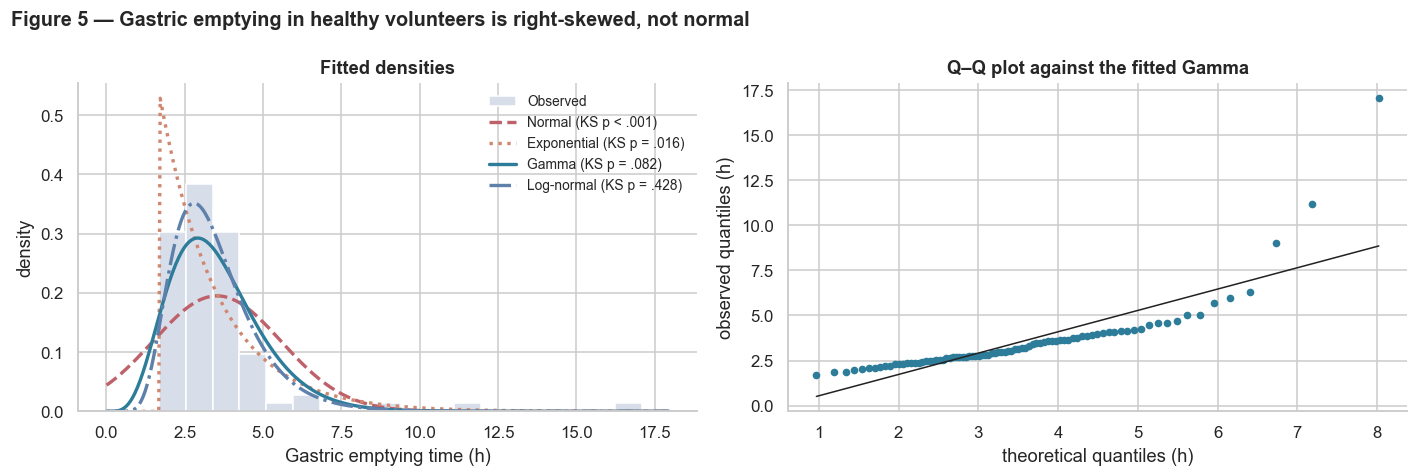

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
ax.hist(x, bins=18, density=True, color="#D8DEE9", edgecolor="white", label="Observed")
grid = np.linspace(0.01, x.max() * 1.05, 400)
styles = {"Normal": ("#BF616A", "--"), "Exponential": ("#D08770", ":"), "Gamma": ("#2D7D9A", "-"), "Log-normal": ("#5E81AC", "-.")}
for name, dist in fits.items():
    colour, ls = styles[name]
    p = fit_table.set_index("Distribution").loc[name, "KS p"]
    ax.plot(grid, dist.pdf(grid), color=colour, ls=ls, lw=2.2, label=f"{name} (KS {p_str(p)})")
ax.set(xlabel="Gastric emptying time (h)", ylabel="density", title="Fitted densities")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
stats.probplot(x, dist=fits["Gamma"], plot=ax)
ax.get_lines()[0].set(color="#2D7D9A", markersize=4)
ax.get_lines()[1].set(color="#222", lw=1)
ax.set(title="Q–Q plot against the fitted Gamma", xlabel="theoretical quantiles (h)", ylabel="observed quantiles (h)")
fig.suptitle("Figure 5 — Gastric emptying in healthy volunteers is right-skewed, not normal",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "fig5_distribution_fit")
plt.show()

* The **normal distribution is clearly rejected** (KS p < .001), and so is the exponential (p = .016).
* The **log-normal** fits best (KS p = .43, lowest AIC among the well-fitting models). The **Gamma** is also not rejected (p = .08). Both are right-skewed, strictly positive distributions, which is typical for physiological waiting times.
* A few volunteers have long GE times (up to 17 h) that sit in the upper tail of every fit.

So GE time is not normal even in healthy people, which again supports rank-based tests for the group comparison. Log-transforming GE time would make it roughly normal.

## 7. Correlation analysis

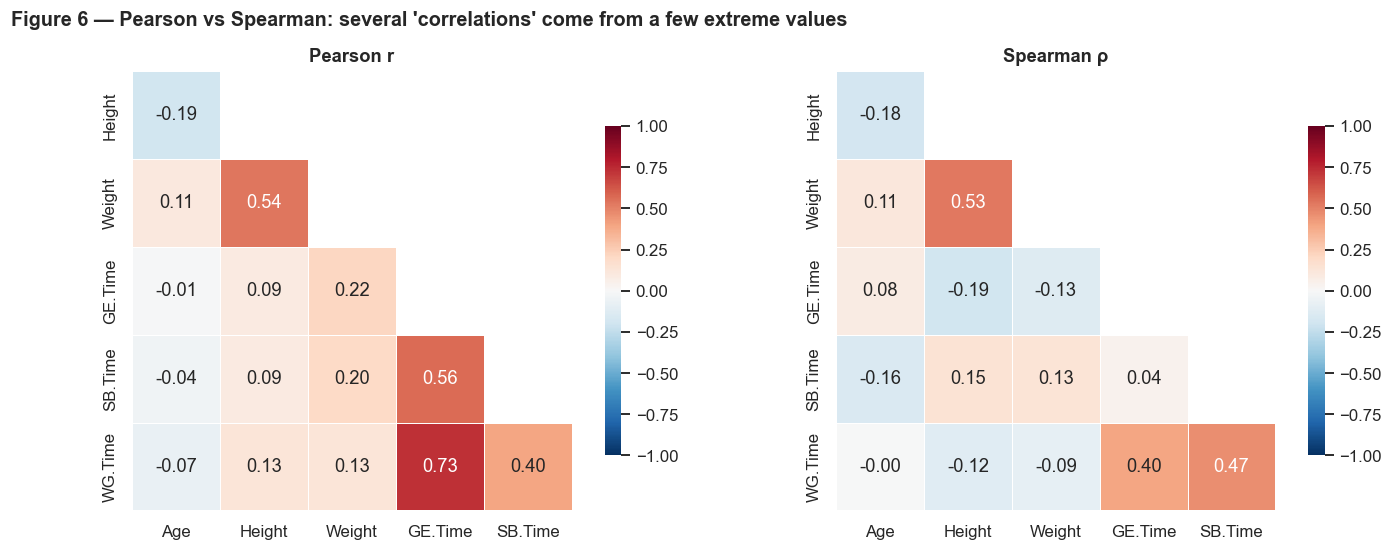

In [17]:
num = ["Age", "Height", "Weight", "GE.Time", "SB.Time", "WG.Time"]
pearson = df[num].corr(method="pearson")
spearman = df[num].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, m) in zip(axes, [("Pearson r", pearson), ("Spearman ρ", spearman)]):
    m = m.iloc[1:, :-1]
    mask = np.triu(np.ones_like(m, dtype=bool), k=1)
    ax.grid(False)
    sns.heatmap(m, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True,
                cbar_kws={"shrink": 0.75}, linewidths=0.5, ax=ax)
    ax.set_title(name)
fig.suptitle("Figure 6 — Pearson vs Spearman: several 'correlations' come from a few extreme values",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "fig6_correlations")
plt.show()

In [18]:
pairs = [(a, b) for i, a in enumerate(num) for b in num[i + 1:]]
corr_rows = []
for a, b in pairs:
    d = df[[a, b]].dropna()
    r, p = stats.pearsonr(d[a], d[b])
    rho, p_s = stats.spearmanr(d[a], d[b])
    corr_rows.append({"Pair": f"{a} – {b}", "n": len(d), "Pearson r": r, "p": fmt_p(p), "Spearman ρ": rho, "p (ρ)": fmt_p(p_s)})
pd.DataFrame(corr_rows).round(3)

,Pair,n,Pearson r,p,Spearman ρ,p (ρ)
0,Age – Height,95,-0.192,.063,-0.184,.074
1,Age – Weight,95,0.107,.300,0.113,.276
2,Age – GE.Time,92,-0.013,.905,0.084,.428
3,Age – SB.Time,90,-0.041,.705,-0.155,.144
4,Age – WG.Time,94,-0.072,.493,-0.005,.964
5,Height – Weight,95,0.538,< .001,0.528,< .001
6,Height – GE.Time,92,0.093,.378,-0.194,.064
7,Height – SB.Time,90,0.087,.412,0.146,.171
8,Height – WG.Time,94,0.127,.223,-0.122,.243
9,Weight – GE.Time,92,0.217,.038,-0.131,.214


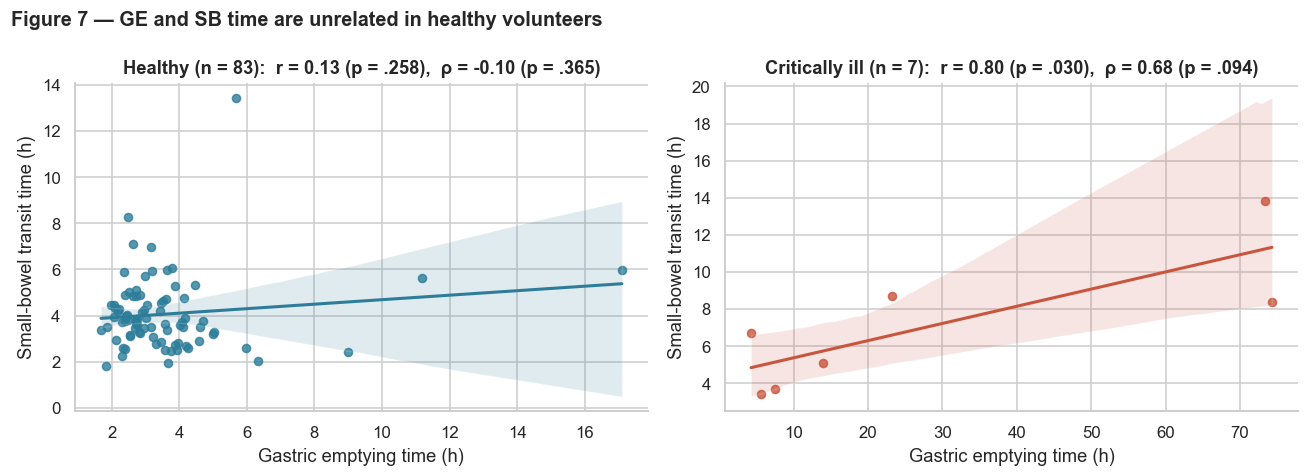

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, (grp, data) in zip(axes, [(HEALTHY, healthy), (ILL, ill)]):
    d = data[["GE.Time", "SB.Time"]].dropna()
    sns.regplot(data=d, x="GE.Time", y="SB.Time", ax=ax, color=PALETTE[grp],
                scatter_kws={"s": 28, "alpha": 0.8}, line_kws={"lw": 2})
    r, p = stats.pearsonr(d["GE.Time"], d["SB.Time"])
    rho, p_s = stats.spearmanr(d["GE.Time"], d["SB.Time"])
    ax.set(xlabel="Gastric emptying time (h)", ylabel="Small-bowel transit time (h)",
           title=f"{grp} (n = {len(d)}):  r = {r:.2f} ({p_str(p)}),  ρ = {rho:.2f} ({p_str(p_s)})")
fig.suptitle("Figure 7 — GE and SB time are unrelated in healthy volunteers",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "fig7_ge_vs_sb")
plt.show()

* **Pearson and Spearman disagree, and that is the key finding.** Pooled over both groups, Pearson gives GE–SB r = 0.57 and GE–WG r = 0.73 (both p < .001). The rank-based Spearman gives GE–SB ρ = 0.04 (p = .69) and GE–WG ρ = 0.40. The large Pearson values come from the handful of patients who are extreme on *both* variables, not from a general linear relationship.
* **Within the healthy volunteers, GE and SB time are unrelated** (r = 0.13, p = .26). Among the 7 patients the correlation is strong (r = 0.80, p = .03), but 7 points are too few to rely on (Spearman p = .09).
* The robust associations are whole-gut time with GE time (ρ = 0.40) and with SB time (ρ = 0.47). That is expected, because whole-gut time includes both segments. The other one is height with weight (r = 0.54).
* Age and height are unrelated to transit. Weight–GE (r = 0.22, p = .04) disappears with Spearman (ρ = −0.13) and would not survive a correction for 15 tests anyway.
* Cronbach's α would **not** be appropriate here. It measures internal consistency of items on one scale, whereas GE and SB time describe different parts of the gut.

## 8. Multiple linear regression: what predicts small-bowel transit time?

Model: `SB.Time ~ GE.Time + Age + Weight + Group`. The predictors are standardised (z-scores), so each coefficient is the change in hours of SB transit per 1 SD increase in that predictor.

In [20]:
reg = df[["SB.Time", "GE.Time", "Age", "Weight", "Group"]].dropna().copy()
z = reg[["GE.Time", "Age", "Weight", "Group"]].apply(lambda s: (s - s.mean()) / s.std())
z.columns = ["GE_z", "Age_z", "Weight_z", "Group_z"]
reg = pd.concat([reg, z], axis=1)

ols = smf.ols("Q('SB.Time') ~ GE_z + Age_z + Weight_z + Group_z", data=reg).fit()
ols_robust = ols.get_robustcov_results(cov_type="HC3")
print(ols.summary(title="SB.Time ~ standardised predictors (n = %d)" % len(reg)))

                  SB.Time ~ standardised predictors (n = 90)                  
Dep. Variable:           Q('SB.Time')   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     10.66
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           4.75e-07
Time:                        13:09:45   Log-Likelihood:                -170.79
No. Observations:                  90   AIC:                             351.6
Df Residuals:                      85   BIC:                             364.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2966      0.175     24.542      0.0

In [21]:
coef = pd.DataFrame({
    "β (h per SD)": ols.params, "SE": ols.bse, "t": ols.tvalues, "p": ols.pvalues,
    "p (HC3 robust)": ols_robust.pvalues,
}).rename(index={"Intercept": "Intercept", "GE_z": "GE time", "Age_z": "Age", "Weight_z": "Weight", "Group_z": "Group (healthy)"})
coef["p"] = coef["p"].map(fmt_p)
coef["p (HC3 robust)"] = coef["p (HC3 robust)"].map(fmt_p)
print(f"R² = {ols.rsquared:.3f},  adjusted R² = {ols.rsquared_adj:.3f},  "
      f"F({int(ols.df_model)}, {int(ols.df_resid)}) = {ols.fvalue:.2f},  p = {fmt_p(ols.f_pvalue)}")
coef.round(3)

R² = 0.334,  adjusted R² = 0.303,  F(4, 85) = 10.66,  p = < .001


,β (h per SD),SE,t,p,p (HC3 robust)
Intercept,4.297,0.175,24.542,< .001,< .001
GE time,0.945,0.234,4.046,< .001,.125
Age,-0.102,0.179,-0.568,.572,.590
Weight,0.190,0.184,1.036,.303,.225
Group (healthy),-0.215,0.228,-0.942,.349,.478


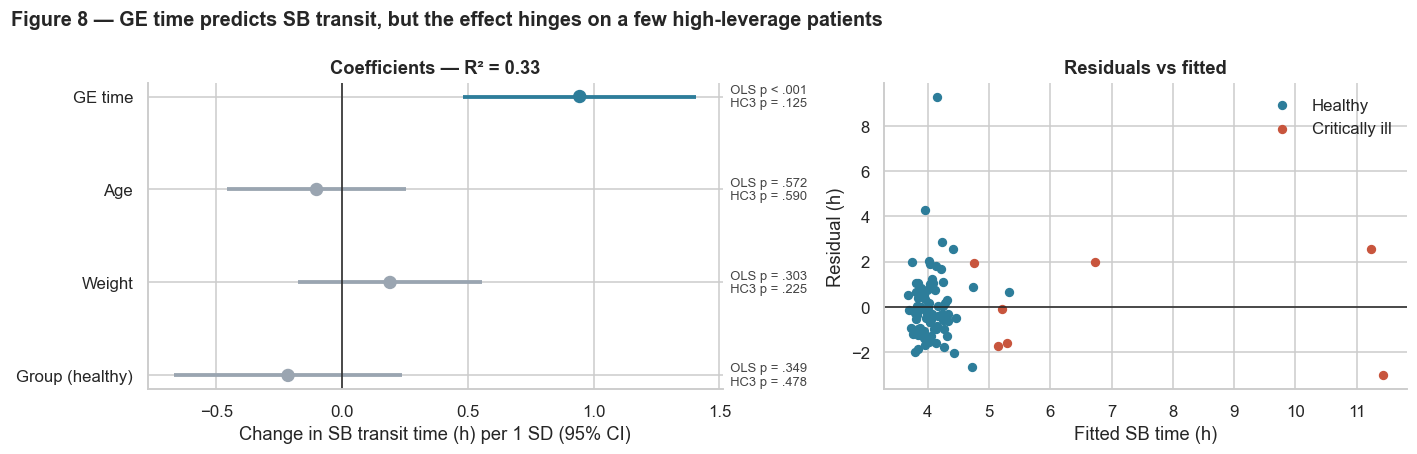

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]
c = ols.params.drop("Intercept")
ci_ = ols.conf_int().drop("Intercept")
labels = ["GE time", "Age", "Weight", "Group (healthy)"]
colours = ["#2D7D9A" if p < 0.05 else "#9AA5B1" for p in ols.pvalues.drop("Intercept")]
ax.hlines(range(len(c)), ci_[0], ci_[1], color=colours, lw=2.5)
ax.scatter(c, range(len(c)), color=colours, s=60, zorder=3)
ax.axvline(0, color="#222", lw=1)
ax.set_yticks(range(len(c)), labels)
ax.invert_yaxis()
ax.set(xlabel="Change in SB transit time (h) per 1 SD (95% CI)", title=f"Coefficients — R² = {ols.rsquared:.2f}")
for i, (pp, pr) in enumerate(zip(ols.pvalues.drop("Intercept"), ols_robust.pvalues[1:])):
    ax.text(ax.get_xlim()[1], i, f"  OLS {p_str(pp)}\n  HC3 {p_str(pr)}", va="center", fontsize=8.5, color="#444")

ax = axes[1]
for g, grp in [(1, HEALTHY), (0, ILL)]:
    sel = reg["Group"] == g
    ax.scatter(ols.fittedvalues[sel], ols.resid[sel], s=26, color=PALETTE[grp], label=grp)
ax.axhline(0, color="#222", lw=1)
ax.legend(frameon=False)
ax.set(xlabel="Fitted SB time (h)", ylabel="Residual (h)", title="Residuals vs fitted")
fig.suptitle("Figure 8 — GE time predicts SB transit, but the effect hinges on a few high-leverage patients",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "fig8_regression")
plt.show()

In [23]:
typical = pd.DataFrame({"GE.Time": [2.72], "Age": [33.5], "Weight": [77.4], "Group": [1]})
tz = (typical - reg[["GE.Time", "Age", "Weight", "Group"]].mean()) / reg[["GE.Time", "Age", "Weight", "Group"]].std()
tz.columns = ["GE_z", "Age_z", "Weight_z", "Group_z"]
pred = ols.get_prediction(tz).summary_frame(alpha=0.05)
print("Predicted SB time for a typical healthy male volunteer (33.5 y, 77.4 kg, GE = 2.72 h): "
      f"{pred['mean'].iloc[0]:.2f} h  (95% prediction interval {pred['obs_ci_lower'].iloc[0]:.1f} – {pred['obs_ci_upper'].iloc[0]:.1f} h)")

Predicted SB time for a typical healthy male volunteer (33.5 y, 77.4 kg, GE = 2.72 h): 4.02 h  (95% prediction interval 0.7 – 7.3 h)


**Interpretation.** The model explains about a third of the variance in SB transit time (R² = 0.33, adjusted 0.30, F(4, 85) = 10.7, p < .001). With ordinary standard errors, **GE time** is the only significant predictor: each 1 SD increase in GE time goes with about 0.9 h more SB transit (p < .001). Age, weight and group are not significant.

**A robustness check changes the picture.** The residuals are strongly non-normal (skew 2.3, Jarque–Bera p < .001) and their variance is larger for the patients. With heteroscedasticity-robust (HC3) standard errors, the GE coefficient is **no longer significant (p = .13)**. This matches the correlation section: the GE–SB link is carried by a few patients with extreme values on both variables (high leverage), not by the volunteers.

**Conclusion.** The data are *consistent with* slow gastric emptying going together with slow small-bowel transit in critically ill patients. But this dataset cannot establish it as a general predictor. A log-transformed outcome, a Gamma GLM or simply more patients would be needed.

## 9. Conclusions

1. **Gastric emptying is delayed about 4.5-fold** in critically ill trauma patients: median 13.9 h vs 3.0 h, Mann–Whitney p < .001.
2. **Small-bowel transit is also prolonged:** 6.7 h vs 3.8 h, p = .010, which stays significant at the Bonferroni α = .025.
3. **Whole-gut transit is about 8 times longer:** median 240 h vs 28 h, p < .001.
4. The groups are well matched on age, height, weight and gender, so these demographics do not explain the differences.
5. Transit times are right-skewed (log-normal or Gamma, not normal), so rank-based tests are the right choice. Welch's *t*-test misses the GE difference (p = .076) because a handful of extreme values inflate the variance.
6. GE time is associated with SB transit in a multiple regression (R² = 0.33). But the effect depends on a few high-leverage patients and is not significant with robust standard errors. Among the healthy volunteers the two times are unrelated.
7. Several apparent correlations (GE–SB, weight–GE) disappear with Spearman's ρ. **Choosing the robust method changes the conclusion**, which may be the main methodological lesson of this dataset.

**Clinical takeaway.** Delayed emptying of both the stomach and the small intestine should be expected in ventilated trauma patients when planning enteral nutrition and watching for feeding intolerance.

**Limitations.** There are only 8 patients (7 with GE data), so estimates are imprecise (for example, the odds-ratio CI runs from about 1 to 277). The control group comes from a different trial (external controls, no randomisation). The patients also differ from the volunteers in medication, sedation and posture. And pH, pressure and race data are missing for all patients.

### Reference
Rauch S, Krueger K, Turan A, You J, Roewer N, Sessler DI. *Use of wireless motility capsule to determine gastric emptying and small intestinal transit times in critically ill trauma patients.* J Crit Care. 2012;27(5):534.e7–534.e12. doi:10.1016/j.jcrc.2011.12.002